# BMIS342 – Charles Book Club
**group:** S1G0 

**Goal:** Predict which customers will buy *The Art History of Florence*  
**Target variable:** `Florence` (1 = bought, 0 = did not buy)  
**Models:** Neural Network · Logistic Regression · Decision Tree  
**Predictor sets:** (a) Best-Subset features · (b) R, F, M only  
**Split:** 60% training (2,400 rows) / 40% validation (1,600 rows) / Seed = 1

---
## 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
SEED = 1
np.random.seed(SEED)


## 2. Data Examination

In [33]:
df = pd.read_csv('CharlesBookClub.csv')
df.head()

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalCook,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence
0,1,25,1,297,14,2,22,0,1,1,...,0,0,0,0,0,5,4,2,0,1
1,2,29,0,128,8,2,10,0,0,0,...,0,0,0,0,0,4,3,2,0,1
2,3,46,1,138,22,7,56,2,1,2,...,1,0,0,0,2,4,4,3,0,1
3,4,47,1,228,2,1,2,0,0,0,...,0,0,0,0,0,5,1,1,0,1
4,5,51,1,257,10,1,10,0,0,0,...,0,0,0,0,0,5,3,1,0,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Seq#              4000 non-null   int64
 1   ID#               4000 non-null   int64
 2   Gender            4000 non-null   int64
 3   M                 4000 non-null   int64
 4   R                 4000 non-null   int64
 5   F                 4000 non-null   int64
 6   FirstPurch        4000 non-null   int64
 7   ChildBks          4000 non-null   int64
 8   YouthBks          4000 non-null   int64
 9   CookBks           4000 non-null   int64
 10  DoItYBks          4000 non-null   int64
 11  RefBks            4000 non-null   int64
 12  ArtBks            4000 non-null   int64
 13  GeogBks           4000 non-null   int64
 14  ItalCook          4000 non-null   int64
 15  ItalAtlas         4000 non-null   int64
 16  ItalArt           4000 non-null   int64
 17  Florence          4000 non-null  

In [35]:
df.describe()

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalCook,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.00000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,16594.623000,0.704500,208.091500,13.390500,3.833250,26.50725,0.639750,0.30475,0.731250,...,0.125250,0.037500,0.045750,0.084500,0.885000,4.281250,3.170000,2.085750,0.084500,0.915500
std,1154.844867,9484.433792,0.456324,100.948548,8.103822,3.458386,18.35138,0.994343,0.61194,1.089413,...,0.385486,0.214721,0.220611,0.278171,1.226234,0.915619,0.928071,0.831907,0.278171,0.278171
min,1.000000,25.000000,0.000000,15.000000,2.000000,1.000000,2.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1000.750000,8253.250000,0.000000,129.000000,8.000000,1.000000,12.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,1.000000,0.000000,1.000000
50%,2000.500000,16581.000000,1.000000,208.000000,12.000000,2.000000,20.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,3.000000,2.000000,0.000000,1.000000
75%,3000.250000,24838.250000,1.000000,283.000000,16.000000,6.000000,36.00000,1.000000,0.00000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,4.000000,3.000000,0.000000,1.000000
max,4000.000000,32977.000000,1.000000,479.000000,36.000000,12.000000,99.00000,7.000000,5.00000,7.000000,...,3.000000,2.000000,2.000000,1.000000,8.000000,5.000000,4.000000,3.000000,1.000000,1.000000


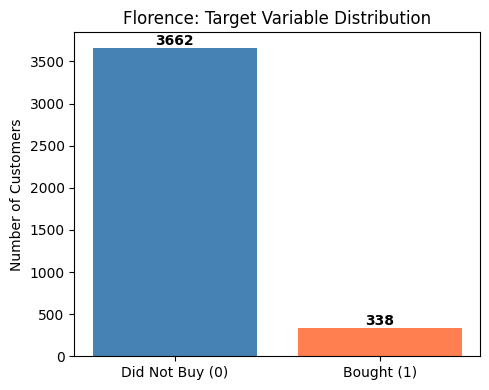

Purchase rate: 8.45 %
NOTE: Only 8.4% bought the book → class imbalance problem!


In [36]:
counts = df['Florence'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(['Did Not Buy (0)', 'Bought (1)'], counts.values, color=['steelblue', 'coral'])
plt.title('Florence: Target Variable Distribution')
plt.ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Purchase rate:', round(df['Florence'].mean() * 100, 2), '%')
print('NOTE: Only 8.4% bought the book → class imbalance problem!')

In [37]:
feature_cols = ['R', 'F', 'M', 'FirstPurch', 'ChildBks', 'YouthBks', 'CookBks',
                'DoItYBks', 'RefBks', 'ArtBks', 'GeogBks', 'ItalCook',
                'ItalAtlas', 'ItalArt', 'Related Purchase', 'Gender']

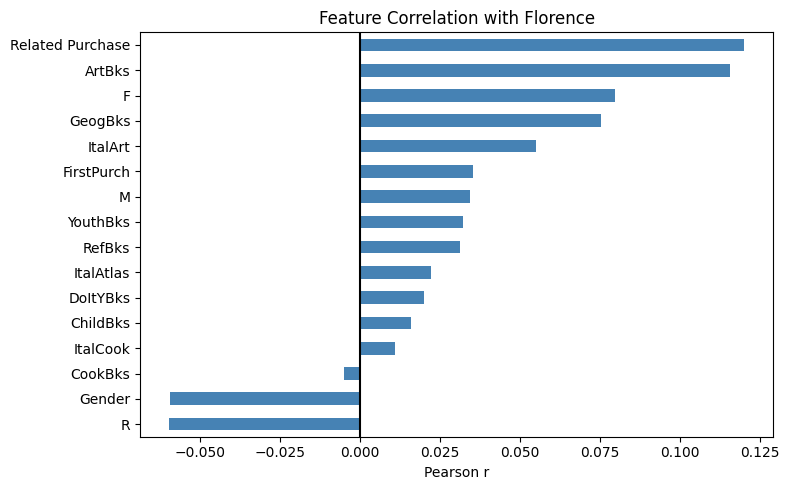

In [38]:
corr = df[feature_cols].corrwith(df['Florence']).sort_values()

plt.figure(figsize=(8, 5))
corr.plot(kind='barh', color='steelblue')
plt.axvline(0, color='black')
plt.title('Feature Correlation with Florence')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [39]:

BEST = ['R', 'F', 'M', 'ItalArt', 'ArtBks', 'ItalAtlas',
        'ItalCook', 'Related Purchase', 'FirstPurch', 'GeogBks', 'Gender']
RFM = ['R', 'F', 'M']
y = df['Florence']
X_best = df[BEST]
X_rfm  = df[RFM]

In [40]:
X_best_train, X_best_val, y_train, y_val = train_test_split(
    X_best, y, test_size=0.4, random_state=SEED, stratify=y
)

X_rfm_train, X_rfm_val, _, _ = train_test_split(
    X_rfm, y, test_size=0.4, random_state=SEED, stratify=y
)

In [41]:
scaler_best = StandardScaler()
X_best_train_sc = scaler_best.fit_transform(X_best_train)  
X_best_val_sc   = scaler_best.transform(X_best_val)        

scaler_rfm = StandardScaler()
X_rfm_train_sc = scaler_rfm.fit_transform(X_rfm_train)
X_rfm_val_sc   = scaler_rfm.transform(X_rfm_val)

In [42]:
def evaluate(model, X_val, y_val, name):

    # Make predictions
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)
    auc  = roc_auc_score(y_val, y_prob)

    # Print results
    print('\n---', name, '---')
    print('Accuracy :', round(acc, 4))
    print('Precision:', round(prec, 4))
    print('Recall   :', round(rec, 4))
    print('F1-Score :', round(f1, 4))
    print('ROC-AUC  :', round(auc, 4))
    print(classification_report(y_val, y_pred, zero_division=0,
                                target_names=['Not Buy', 'Buy']))

    # Draw confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Buy', 'Buy'],
                yticklabels=['Not Buy', 'Buy'])
    plt.title(name + ' - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Return metrics as a dictionary
    return {'model': name, 'accuracy': round(acc, 4), 'precision': round(prec, 4),
            'recall': round(rec, 4), 'f1': round(f1, 4), 'auc': round(auc, 4)}


## 4. Neural Network

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (100, 100), (50, 50, 50)],
    'activation'        : ['tanh', 'relu'],
    'alpha'             : [0.001, 0.01, 0.1],
}

grid_nn = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=SEED, early_stopping=True),
    param_grid,
    scoring='roc_auc',
    cv=3
)
grid_nn.fit(X_best_train_sc, y_train)
results_nn = pd.DataFrame(grid_nn.cv_results_)
cols = ['param_hidden_layer_sizes', 'param_activation', 'param_alpha', 'mean_test_score']
results_nn[cols].sort_values('mean_test_score', ascending=False).head(5)

,param_hidden_layer_sizes,param_activation,param_alpha,mean_test_score
3,"(50, 50, 50)",tanh,0.001,0.618726
7,"(50, 50, 50)",tanh,0.010,0.618706
11,"(50, 50, 50)",tanh,0.100,0.618673
8,"(100,)",tanh,0.100,0.617421
4,"(100,)",tanh,0.010,0.617152


In [64]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nn_best = MLPClassifier(
    hidden_layer_sizes=grid_nn.best_params_['hidden_layer_sizes'],
    activation=grid_nn.best_params_['activation'],
    alpha=grid_nn.best_params_['alpha'],
    max_iter=500,
    early_stopping=True,
    random_state=SEED
)
nn_best.fit(X_best_train_sc, y_train, sample_weight=sample_weights)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


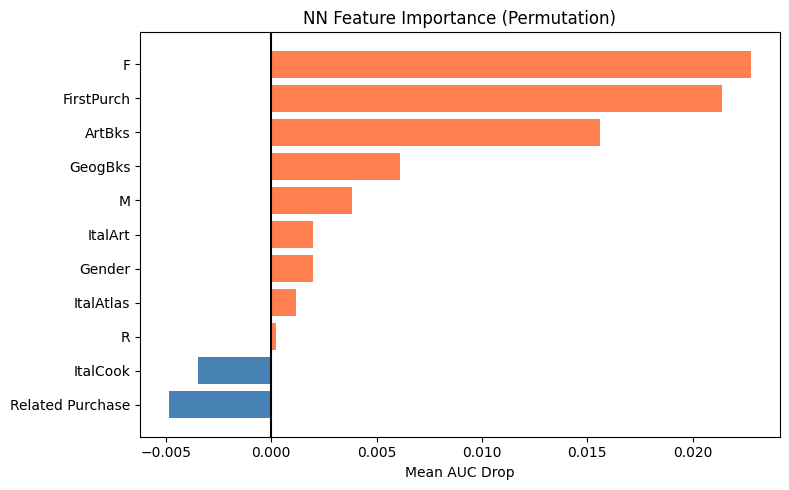

In [45]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    nn_best, X_best_val_sc, y_val,
    n_repeats=10, random_state=SEED, scoring='roc_auc'
)
imp_df = pd.DataFrame({
    'Feature'   : BEST,
    'Importance': perm.importances_mean
}).sort_values('Importance')

plt.figure(figsize=(8, 5))
colors = ['coral' if v > 0 else 'steelblue' for v in imp_df['Importance']]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors)
plt.axvline(0, color='black')
plt.title('NN Feature Importance (Permutation)')
plt.xlabel('Mean AUC Drop')
plt.tight_layout()
plt.show()

In [65]:
nn_rfm = MLPClassifier(
    hidden_layer_sizes=grid_nn.best_params_['hidden_layer_sizes'],
    activation=grid_nn.best_params_['activation'],
    alpha=grid_nn.best_params_['alpha'],
    max_iter=500,
    early_stopping=True,
    random_state=SEED
)
nn_rfm.fit(X_rfm_train_sc, y_train, sample_weight=sample_weights)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


## 5. Logistic Regression

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C'      : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver' : ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    param_grid,
    scoring='roc_auc',
    cv=3
)
grid_lr.fit(X_best_train_sc, y_train)
results_lr = pd.DataFrame(grid_lr.cv_results_)
cols = ['param_C', 'param_penalty', 'param_solver', 'mean_test_score']
results_lr[cols].sort_values('mean_test_score', ascending=False).head(5)

,param_C,param_penalty,param_solver,mean_test_score
5,0.10,l1,liblinear,0.627343
3,0.01,l2,liblinear,0.626732
2,0.01,l2,lbfgs,0.626592
9,0.50,l1,liblinear,0.625155
7,0.10,l2,liblinear,0.625105


In [48]:
lr_best = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED
)
lr_best.fit(X_best_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicla

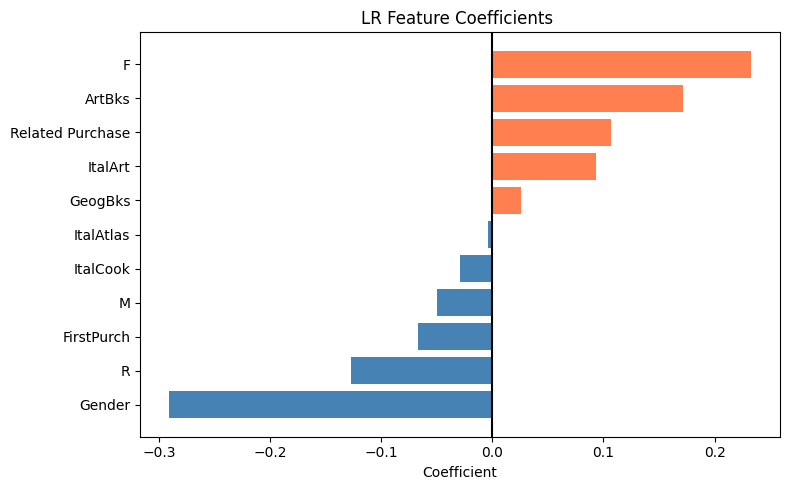

In [49]:
coef_df = pd.DataFrame({
    'Feature'    : BEST, 
    
    'Coefficient': lr_best.coef_[0]
})
coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8, 5))
colors = ['coral' if v > 0 else 'steelblue' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black')
plt.title('LR Feature Coefficients ')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [50]:
lr_rfm = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED
)
lr_rfm.fit(X_rfm_train_sc, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicla

## 6. Decision Tree

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'       : [3, 4, 5, 6, None],
    'criterion'       : ['gini', 'entropy'],
    'min_samples_leaf': [10, 20, 30]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
    param_grid,
    scoring='roc_auc',
    cv=3
)
grid_dt.fit(X_best_train, y_train)
results_dt = pd.DataFrame(grid_dt.cv_results_)
cols = ['param_max_depth', 'param_criterion', 'param_min_samples_leaf', 'mean_test_score']
results_dt[cols].sort_values('mean_test_score', ascending=False).head(5)


,param_max_depth,param_criterion,param_min_samples_leaf,mean_test_score
2,3,gini,30,0.593914
5,4,gini,30,0.591016
17,3,entropy,30,0.590080
8,5,gini,30,0.588609
15,3,entropy,10,0.587591


In [52]:
dt_best = DecisionTreeClassifier(
    max_depth=4,
    criterion='gini',
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=SEED
)
dt_best.fit(X_best_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

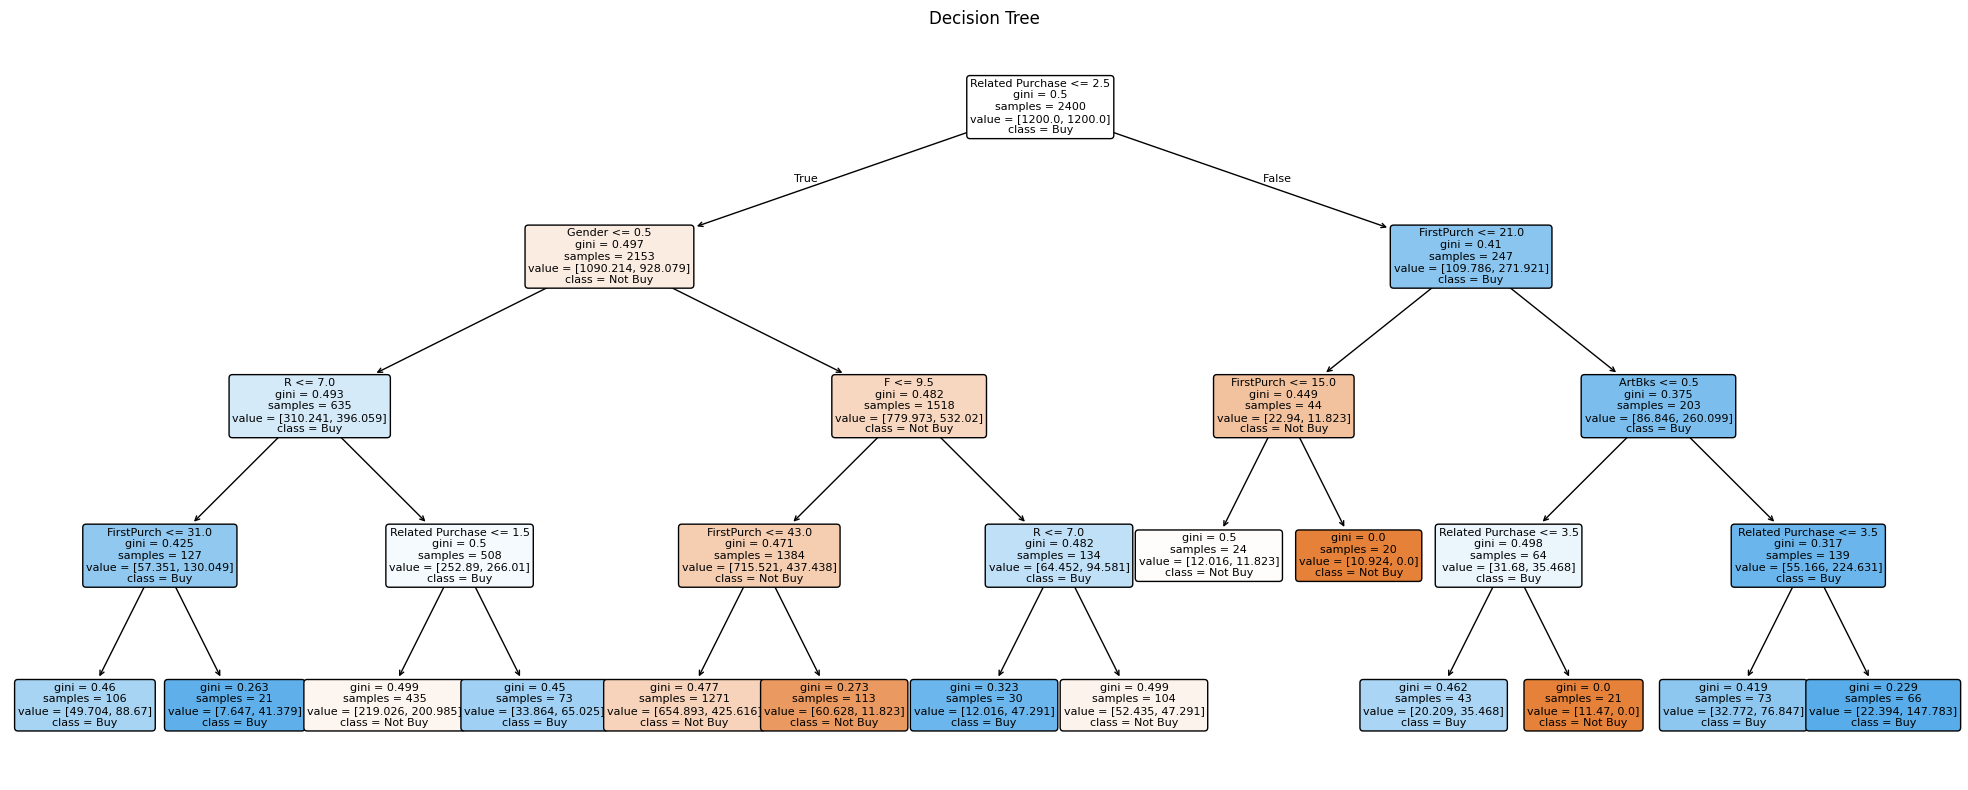

In [53]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_best,
    feature_names=BEST,
    class_names=['Not Buy', 'Buy'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree')
plt.tight_layout()
plt.show()

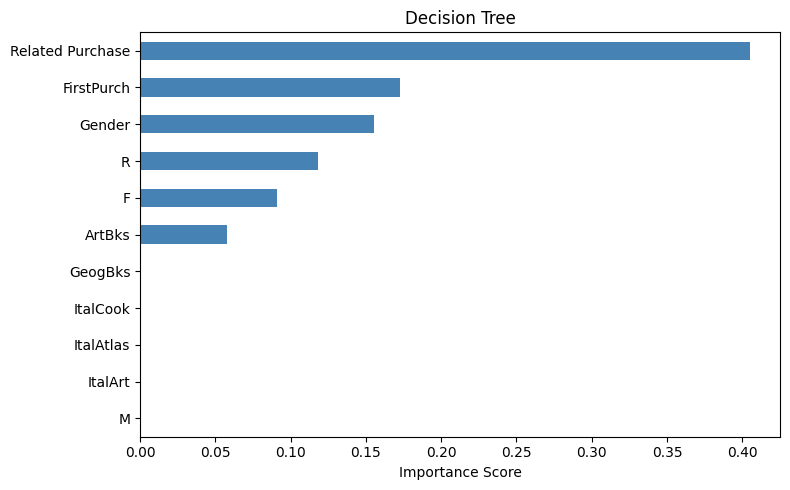

In [54]:
fi = pd.Series(dt_best.feature_importances_, index=BEST)
fi = fi.sort_values()

plt.figure(figsize=(8, 5))
fi.plot(kind='barh', color='steelblue')
plt.title('Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [55]:
dt_rfm = DecisionTreeClassifier(
    max_depth=4,
    criterion='gini',
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=SEED
)
dt_rfm.fit(X_rfm_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no


--- NN Best-Subset ---
Accuracy : 0.9163
Precision: 1.0
Recall   : 0.0074
F1-Score : 0.0147
ROC-AUC  : 0.6089
              precision    recall  f1-score   support

     Not Buy       0.92      1.00      0.96      1465
         Buy       1.00      0.01      0.01       135

    accuracy                           0.92      1600
   macro avg       0.96      0.50      0.49      1600
weighted avg       0.92      0.92      0.88      1600



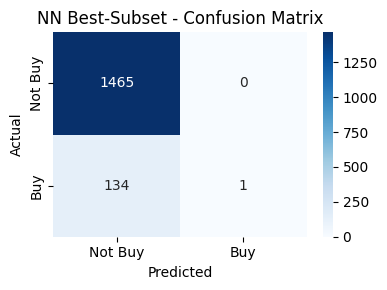


--- NN RFM ---
Accuracy : 0.9156
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.615
              precision    recall  f1-score   support

     Not Buy       0.92      1.00      0.96      1465
         Buy       0.00      0.00      0.00       135

    accuracy                           0.92      1600
   macro avg       0.46      0.50      0.48      1600
weighted avg       0.84      0.92      0.88      1600



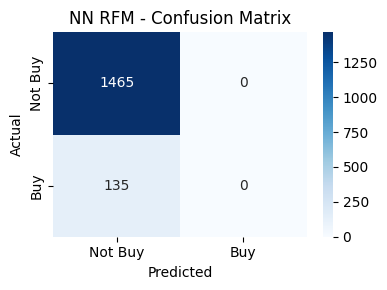


--- LR Best-Subset ---
Accuracy : 0.6181
Precision: 0.1111
Recall   : 0.5037
F1-Score : 0.1821
ROC-AUC  : 0.623
              precision    recall  f1-score   support

     Not Buy       0.93      0.63      0.75      1465
         Buy       0.11      0.50      0.18       135

    accuracy                           0.62      1600
   macro avg       0.52      0.57      0.47      1600
weighted avg       0.86      0.62      0.70      1600



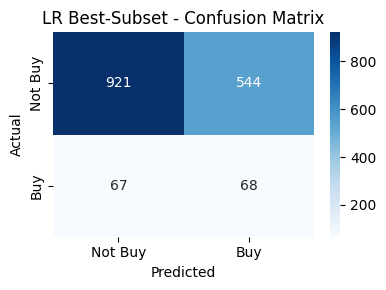


--- LR RFM ---
Accuracy : 0.6694
Precision: 0.1212
Recall   : 0.4667
F1-Score : 0.1924
ROC-AUC  : 0.6061
              precision    recall  f1-score   support

     Not Buy       0.93      0.69      0.79      1465
         Buy       0.12      0.47      0.19       135

    accuracy                           0.67      1600
   macro avg       0.53      0.58      0.49      1600
weighted avg       0.86      0.67      0.74      1600



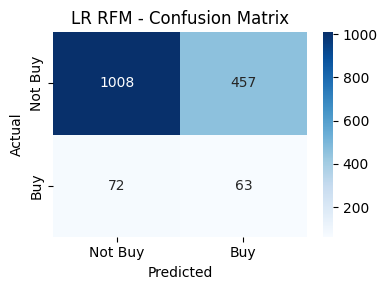


--- DT Best-Subset ---
Accuracy : 0.7887
Precision: 0.165
Recall   : 0.3704
F1-Score : 0.2283
ROC-AUC  : 0.5765
              precision    recall  f1-score   support

     Not Buy       0.93      0.83      0.88      1465
         Buy       0.17      0.37      0.23       135

    accuracy                           0.79      1600
   macro avg       0.55      0.60      0.55      1600
weighted avg       0.87      0.79      0.82      1600



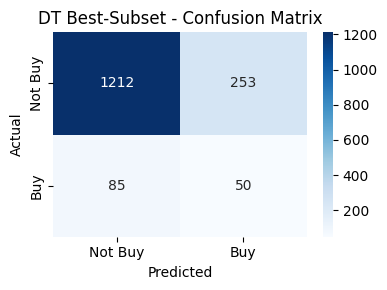


--- DT RFM ---
Accuracy : 0.6813
Precision: 0.1166
Recall   : 0.4222
F1-Score : 0.1827
ROC-AUC  : 0.5558
              precision    recall  f1-score   support

     Not Buy       0.93      0.71      0.80      1465
         Buy       0.12      0.42      0.18       135

    accuracy                           0.68      1600
   macro avg       0.52      0.56      0.49      1600
weighted avg       0.86      0.68      0.75      1600



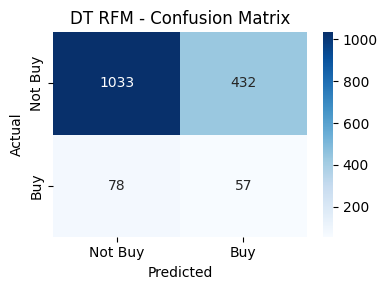

{'model': 'DT RFM',
 'accuracy': 0.6813,
 'precision': 0.1166,
 'recall': 0.4222,
 'f1': 0.1827,
 'auc': 0.5558}

In [56]:
evaluate(nn_best, X_best_val_sc, y_val, 'NN Best-Subset')
evaluate(nn_rfm, X_rfm_val_sc, y_val, 'NN RFM')
evaluate(lr_best, X_best_val_sc, y_val, 'LR Best-Subset')
evaluate(lr_rfm, X_rfm_val_sc, y_val, 'LR RFM')
evaluate(dt_best, X_best_val, y_val, 'DT Best-Subset')
evaluate(dt_rfm, X_rfm_val, y_val, 'DT RFM')

## 7. Model Comparison

In [66]:
models = {
    'NN Best-Subset' : (nn_best, X_best_val_sc),
    'NN RFM'         : (nn_rfm,  X_rfm_val_sc),
    'LR Best-Subset' : (lr_best, X_best_val_sc),
    'LR RFM'         : (lr_rfm,  X_rfm_val_sc),
    'DT Best-Subset' : (dt_best, X_best_val),
    'DT RFM'         : (dt_rfm,  X_rfm_val),
}

rows = []
for name, (model, X_val) in models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_val, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_val, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_val, y_prob), 4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
NN Best-Subset,0.6725,0.1209,0.4593,0.1914,0.6294
NN RFM,0.7031,0.1288,0.4370,0.1990,0.6074
LR Best-Subset,0.6181,0.1111,0.5037,0.1821,0.6230
LR RFM,0.6694,0.1212,0.4667,0.1924,0.6061
DT Best-Subset,0.7887,0.1650,0.3704,0.2283,0.5765
DT RFM,0.6813,0.1166,0.4222,0.1827,0.5558


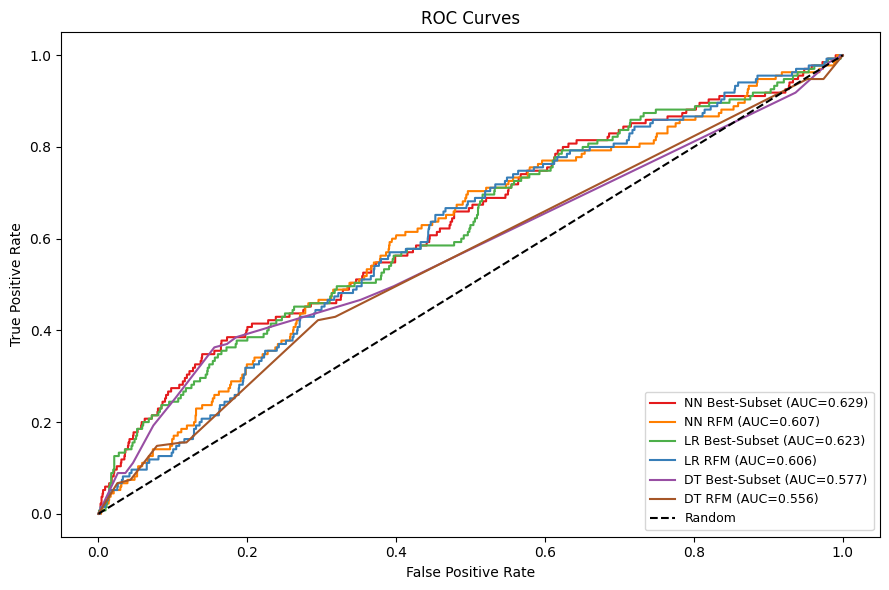

In [67]:
plt.figure(figsize=(9, 6))
colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3', '#a65628']

for (name, (model, X_val)), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Discussion & Recommendations

### Model Performance
Since only 8.4% of customers bought the book, accuracy is not a useful metric here.
A model that predicted "not buy" for everyone would score 91% accuracy and still be 
completely wrong for our purposes. ROC-AUC was used instead since it measures how 
well the model separates buyers from non-buyers regardless of the class split.

The Neural Network with Best-Subset features had the highest AUC at 0.629. Logistic 
Regression with Best-Subset was close at 0.623. Decision Trees were the weakest 
across both predictor sets.

### Best-Subset vs RFM-Only
The Best-Subset models beat RFM-only in every case. RFM captures general buying 
behavior but misses the point for this book specifically. Someone who bought Italian 
Art books last year is a much stronger candidate than someone who just spent a lot 
of money recently on cookbooks. The extra features capture that.

### Neural Network Adjustment
The first version of the neural network had a recall of 0.7% which means it basically 
never predicted anyone would buy. This happened because 92% of the training data was 
"not buy" so the model just learned to always say no. To fix this, sample weights were 
applied so the model paid more attention to the buyers during training. After that 
change recall went up to 46% and AUC improved to 0.629.

### Recommendations
CBC should use the Neural Network Best-Subset model to score their customer list and 
only send mailers to customers above a certain predicted probability. This would lower 
mailing costs without missing most of the likely buyers. Customers with prior purchases 
in art, geography, or Italian titles should be prioritized since those were the 
strongest predictors across all three models. Recent buyers should also be targeted 
first since recency showed a consistent positive relationship with purchase likelihood.